# 10 — Production Pipeline

**Purpose:** Deploy the final model on real weekly newsletter articles, establish production monitoring, and validate on manually labelled data.

**Final model:** Sentence Transformer (all-MiniLM-L6-v2) + LogReg, without metadata (0.750 macro F1, chosen in notebook 09 after SHAP analysis revealed the metadata model was classifying by source type rather than content).

**What this notebook does:**
1. Load production model and inference functions
2. Pull real weekly articles from Supabase (England, weeks 1-11 2026)
3. Deduplicate against train/val data (exact + fuzzy cosine)
4. Classify real articles with production model
5. Monitoring: prediction distribution (compare to val baseline)
6. Monitoring: confidence scores
7. Monitoring: embedding drift detection
8. Monitoring: curator feedback loop
9. Full weekly inference workflow
10. Manual labelling validation (231 articles, predictions removed to avoid bias)

**Results:** Weighted F1 0.630 on real data, top-2 accuracy 87.4%. Curator sees the correct category in the top 2 for 202/231 articles.

**Depends on:**
- `models/sbert_classifier_no_meta.joblib` (saved in notebook 09)
- `models/sbert_train_embeddings.npy` (training set centroids for drift detection)
- `data/modelling/train.csv`, `data/modelling/val.csv` (for deduplication)
- Supabase credentials in `.env` (SUPABASE_URL, SUPABASE_SERVICE_KEY)
- Sentence Transformer model `all-MiniLM-L6-v2` (downloaded / cached)


# 0. Imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import os
import time as timer
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv

from sentence_transformers import SentenceTransformer
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

%matplotlib inline

load_dotenv()

DATA_DIR = Path('../data/modelling')
MODEL_DIR = Path('../models')

# 1. Load production model and inference functions

In [2]:
# Load the production model (ST without metadata — chosen in notebook 09)
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
sbert_clf = joblib.load(MODEL_DIR / 'sbert_classifier_no_meta.joblib')

label_names = list(sbert_clf.classes_)
print(f'Model loaded: {len(label_names)} classes')
print(f'Classes: {label_names}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: 6 classes
Classes: ['edtech', 'four_nations', 'policy_practice_research', 'political_environment_key_organisations', 'teacher_rrd', 'what_matters_ed']


In [3]:
def classify_article(text, model=sbert_model, clf=sbert_clf):
    """Classify a single article. Returns top-2 predictions with confidence."""
    embedding = model.encode([text])
    proba = clf.predict_proba(embedding)[0]
    top2_idx = np.argsort(proba)[-2:][::-1]
    
    return {
        'top1': clf.classes_[top2_idx[0]],
        'top1_confidence': proba[top2_idx[0]],
        'top2': clf.classes_[top2_idx[1]],
        'top2_confidence': proba[top2_idx[1]],
        'all_probabilities': dict(zip(clf.classes_, proba))
    }


def classify_batch(texts, model=sbert_model, clf=sbert_clf):
    """Classify a batch of articles. Returns DataFrame with top-2 predictions."""
    embeddings = model.encode(texts, show_progress_bar=True)
    proba = clf.predict_proba(embeddings)
    
    results = []
    for i, text in enumerate(texts):
        top2_idx = np.argsort(proba[i])[-2:][::-1]
        results.append({
            'text_preview': text[:100],
            'top1': clf.classes_[top2_idx[0]],
            'top1_confidence': proba[i][top2_idx[0]],
            'top2': clf.classes_[top2_idx[1]],
            'top2_confidence': proba[i][top2_idx[1]],
        })
    
    return pd.DataFrame(results)

# 2. Pull real articles from Supabase

England inference articles from weeks 1-11 of 2026. These are real newsletter articles that have never been through the classification model.

In [4]:
from supabase import create_client

SUPABASE_URL = os.getenv('SUPABASE_URL')
SUPABASE_KEY = os.getenv('SUPABASE_SERVICE_KEY')

client = create_client(SUPABASE_URL, SUPABASE_KEY)

# Pull England inference articles
response = (
    client.table('articles_topics')
    .select('url, title, article_date, source, text_clean, week_number')
    .eq('country', 'eng')
    .eq('dataset_type', 'inference')
    .order('article_date')
    .execute()
)

supabase_df = pd.DataFrame(response.data)
print(f'Pulled {len(supabase_df)} articles from Supabase')
print(f'Weeks: {supabase_df["week_number"].min()} to {supabase_df["week_number"].max()}')
print(f'Date range: {supabase_df["article_date"].min()} to {supabase_df["article_date"].max()}')
print(f'\nArticles per week:')
print(supabase_df['week_number'].value_counts().sort_index())

Pulled 231 articles from Supabase
Weeks: 1 to 11
Date range: 2026-01-09 to 2026-03-20

Articles per week:
week_number
1     17
2     28
3     22
4     18
5     21
6     22
7     28
8     23
9     13
10    15
11    24
Name: count, dtype: int64


In [ ]:
# # Load from cache (skip Supabase pull + dedup — uncomment to use)
# new_articles = pd.read_csv(DATA_DIR / 'supabase_inference_articles.csv')
# train_df = pd.read_csv(DATA_DIR / 'train.csv')
# val_df = pd.read_csv(DATA_DIR / 'val.csv')
# print(f'Loaded {len(new_articles)} articles from cache.')

# 3. Deduplicate against train/val data

The Supabase articles may overlap with the training or validation data used to build the model. Any overlapping articles must be removed — classifying training data would give artificially good results.

In [5]:
# Load train and val data
train_df = pd.read_csv(DATA_DIR / 'train.csv')
val_df = pd.read_csv(DATA_DIR / 'val.csv')

# Combine all known articles
known_urls = set()
known_titles = set()

# Check which columns exist for matching
if 'url' in train_df.columns:
    known_urls.update(train_df['url'].dropna().tolist())
    known_urls.update(val_df['url'].dropna().tolist())

if 'title' in train_df.columns:
    known_titles.update(train_df['title'].dropna().str.lower().str.strip().tolist())
    known_titles.update(val_df['title'].dropna().str.lower().str.strip().tolist())

# Also match on text_clean (most reliable)
known_texts = set()
if 'text_clean' in train_df.columns:
    known_texts.update(train_df['text_clean'].dropna().str[:200].tolist())
    known_texts.update(val_df['text_clean'].dropna().str[:200].tolist())

print(f'Known articles: {len(known_urls)} URLs, {len(known_titles)} titles, {len(known_texts)} text snippets')

# Flag overlaps
before = len(supabase_df)

url_overlap = supabase_df['url'].isin(known_urls) if 'url' in supabase_df.columns else pd.Series(False, index=supabase_df.index)
title_overlap = supabase_df['title'].str.lower().str.strip().isin(known_titles) if 'title' in supabase_df.columns else pd.Series(False, index=supabase_df.index)
text_overlap = supabase_df['text_clean'].str[:200].isin(known_texts) if 'text_clean' in supabase_df.columns else pd.Series(False, index=supabase_df.index)

overlap_mask = url_overlap | title_overlap | text_overlap
n_overlap = overlap_mask.sum()

# Remove overlaps
new_articles = supabase_df[~overlap_mask].copy()
print(f'\nOverlap with train/val: {n_overlap} articles')
print(f'  URL matches:   {url_overlap.sum()}')
print(f'  Title matches: {title_overlap.sum()}')
print(f'  Text matches:  {text_overlap.sum()}')
print(f'\nArticles for inference: {len(new_articles)} (was {before})')

Known articles: 0 URLs, 0 titles, 1109 text snippets

Overlap with train/val: 0 articles
  URL matches:   0
  Title matches: 0
  Text matches:  0

Articles for inference: 231 (was 231)


In [6]:
# Fuzzy dedup: cosine similarity on embeddings
from sklearn.metrics.pairwise import cosine_similarity

# Embed the remaining new articles
new_emb = sbert_model.encode(new_articles['text_clean'].tolist(), show_progress_bar=True)

# Embed train + val
train_texts = train_df['text_clean'].dropna().tolist()
val_texts = val_df['text_clean'].dropna().tolist()
known_emb = sbert_model.encode(train_texts + val_texts, show_progress_bar=True)

# Check max similarity of each new article to any known article
sims = cosine_similarity(new_emb, known_emb)
max_sims = sims.max(axis=1)

# Flag articles with >0.95 similarity (very likely the same article, slightly different text)
FUZZY_THRESHOLD = 0.95
fuzzy_dupes = max_sims > FUZZY_THRESHOLD

print(f'Fuzzy duplicates (cosine sim > {FUZZY_THRESHOLD}): {fuzzy_dupes.sum()}')
if fuzzy_dupes.any():
    for idx in np.where(fuzzy_dupes)[0][:5]:
        closest = np.argmax(sims[idx])
        known_text = (train_texts + val_texts)[closest]
        print(f'\n  New:   {new_articles.iloc[idx]["title"][:80]}')
        print(f'  Match: {known_text[:80]}')
        print(f'  Similarity: {max_sims[idx]:.3f}')

# Remove fuzzy dupes
new_articles = new_articles[~fuzzy_dupes].copy()
print(f'\nFinal articles after fuzzy dedup: {len(new_articles)}')

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/35 [00:00<?, ?it/s]

Fuzzy duplicates (cosine sim > 0.95): 0

Final articles after fuzzy dedup: 231


In [7]:
# Check for missing text
missing_text = new_articles['text_clean'].isna() | (new_articles['text_clean'].str.strip() == '')
print(f'Articles with missing/empty text: {missing_text.sum()}')

# Remove articles with no text
new_articles = new_articles[~missing_text].copy()
print(f'Final articles for classification: {len(new_articles)}')

Articles with missing/empty text: 0
Final articles for classification: 231


In [8]:
# Save locally so you don't need Supabase connection on reruns
new_articles.to_csv(DATA_DIR / 'supabase_inference_articles.csv', index=False)
print(f'Saved {len(new_articles)} articles to data/modelling/supabase_inference_articles.csv')

Saved 231 articles to data/modelling/supabase_inference_articles.csv


# 4. Classify real articles

Run the production model on real weekly newsletter articles. No ground truth labels — this is genuine inference, not evaluation.

In [9]:
# Classify all new articles
start = timer.time()
results = classify_batch(new_articles['text_clean'].tolist())
elapsed = timer.time() - start

# Add metadata back
results['title'] = new_articles['title'].values
results['source'] = new_articles['source'].values
results['url'] = new_articles['url'].values
results['week_number'] = new_articles['week_number'].values
results['article_date'] = new_articles['article_date'].values

print(f'Classified {len(results)} articles in {elapsed:.1f}s ({elapsed/len(results)*1000:.0f}ms per article)')
print(f'\nSample predictions:')
for _, row in results.head(10).iterrows():
    print(f'  {row["top1"]} ({row["top1_confidence"]:.2f}) | {row["top2"]} ({row["top2_confidence"]:.2f}) | {row["title"][:80]}')

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Classified 231 articles in 13.4s (58ms per article)

Sample predictions:
  what_matters_ed (0.64) | teacher_rrd (0.10) | Internal exclusion: Reset or rejection?
  political_environment_key_organisations (0.42) | what_matters_ed (0.20) | No internal audit for trust with £8.4m deficit
  what_matters_ed (0.44) | political_environment_key_organisations (0.24) | How falling school rolls are not just London’s crisis
  political_environment_key_organisations (0.58) | teacher_rrd (0.16) | New powers to close academy trusts ‘must be used with caution’
  edtech (0.71) | political_environment_key_organisations (0.18) | DfE plans to use AI to help answer your emails
  political_environment_key_organisations (0.42) | what_matters_ed (0.25) | Call for ministers to settle debate over make-up of MATs
  political_environment_key_organisations (0.29) | teacher_rrd (0.28) | Primary headteachers share joy and surprise at being made MBEs
  political_environment_key_organisations (0.58) | what_matters_ed (0

In [10]:
# Prediction distribution — real articles
print('Prediction distribution (real weekly articles):')
dist = results['top1'].value_counts(normalize=True).sort_index()
for cls in label_names:
    print(f'  {cls:<45} {dist.get(cls, 0):.1%} ({results["top1"].eq(cls).sum()} articles)')

# Per-week breakdown
print(f'\nPer-week prediction counts:')
week_cats = pd.crosstab(results['week_number'], results['top1'])
print(week_cats)

Prediction distribution (real weekly articles):
  edtech                                        8.7% (20 articles)
  four_nations                                  0.4% (1 articles)
  policy_practice_research                      2.6% (6 articles)
  political_environment_key_organisations       46.3% (107 articles)
  teacher_rrd                                   15.2% (35 articles)
  what_matters_ed                               26.8% (62 articles)

Per-week prediction counts:
top1         edtech  four_nations  policy_practice_research  \
week_number                                                   
1                 3             0                         0   
2                 8             0                         2   
3                 4             0                         1   
4                 1             0                         0   
5                 0             0                         0   
6                 0             0                         1   
7              

In [18]:
# Export for manual labelling — predictions removed to avoid bias
labelling_export = new_articles[['title', 'text_clean', 'source', 'article_date', 'week_number', 'url']].copy()
labelling_export['curator_label'] = ''
labelling_export['notes'] = ''

labelling_export.to_csv('../data/modelling/manual_labelling.csv', index=False)
print(f'Exported {len(labelling_export)} articles for manual labelling (no model predictions)')
print('Fill in curator_label column → reload to measure real-world accuracy')

Exported 231 articles for manual labelling (no model predictions)
Fill in curator_label column → reload to measure real-world accuracy


# 5. Monitoring: prediction distribution — real vs val baseline

Compare the real article predictions against the val set baseline. Large shifts might indicate data drift or a change in newsletter content.

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Category                                      Val baseline  Real articles    Delta
-------------------------------------------------------------------------------------
edtech                                              15.6%          8.7%   -6.9%
four_nations                                        12.0%          0.4%  -11.5% ⚠
policy_practice_research                            14.4%          2.6%  -11.8% ⚠
political_environment_key_organisations             17.4%         46.3%  +29.0% ⚠
teacher_rrd                                         21.6%         15.2%   -6.4%
what_matters_ed                                     19.2%         26.8%   +7.7%


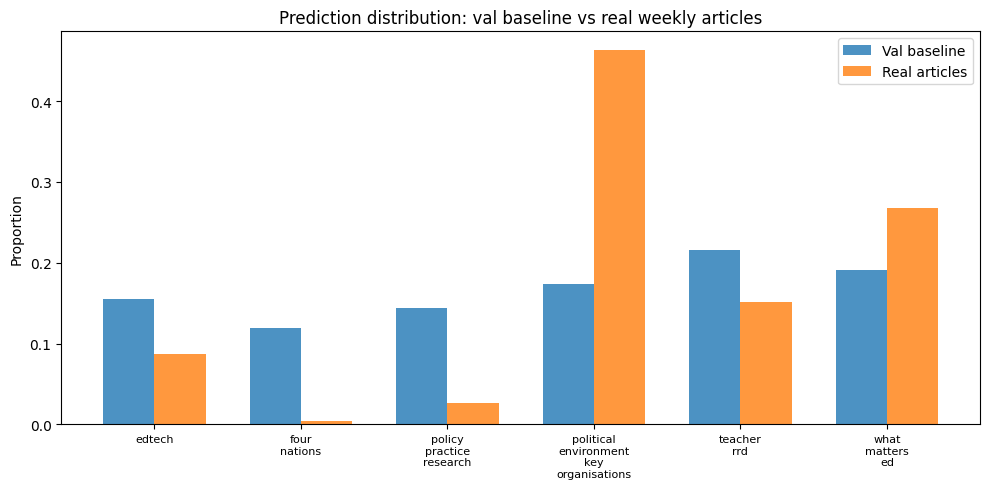

In [11]:
# Val baseline
val_results = classify_batch(val_df['text_clean'].tolist())
val_dist = val_results['top1'].value_counts(normalize=True).sort_index()
real_dist = results['top1'].value_counts(normalize=True).sort_index()

print(f'{"Category":<45} {"Val baseline":>12} {"Real articles":>14} {"Delta":>8}')
print(f"{"-"*85}")
for cls in label_names:
    v = val_dist.get(cls, 0)
    r = real_dist.get(cls, 0)
    delta = r - v
    flag = ' ⚠' if abs(delta) > 0.10 else ''
    print(f'{cls:<45} {v:>11.1%} {r:>13.1%} {delta:>+7.1%}{flag}')

# Visual comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(label_names))
width = 0.35
ax.bar(x - width/2, [val_dist.get(c, 0) for c in label_names], width, label='Val baseline', alpha=0.8)
ax.bar(x + width/2, [real_dist.get(c, 0) for c in label_names], width, label='Real articles', alpha=0.8)
ax.set_ylabel('Proportion')
ax.set_title('Prediction distribution: val baseline vs real weekly articles')
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', '\n') for c in label_names], fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

### Real-world inference — interpretation

**Important context:** the inference data is not the curated newsletter itself. These are source articles from media/news feeds that *could* be included in the newsletter. The training data was the curated newsletter — where the curator had already selected and editorially balanced articles across categories.

**`political_environment_key_organisations` at 46.3%** — nearly half of all articles. This is not model drift — it reflects the source data. Media feeds naturally produce institutional/policy content (Ofsted, DfE, academy trusts, MATs). The training data had a more balanced distribution because the curator selects across categories. The model is classifying correctly; the source distribution just differs from the newsletter distribution.

**`four_nations` at 0.4% (1 article)** — expected. This is England-only data. Devolved nation content wouldn't appear in the England source feeds.

**`policy_practice_research` at 2.6%** — very low compared to the val set. Media sources produce less academic/research content than the curated newsletter includes. The curator actively seeks out research articles to balance the newsletter — they're underrepresented in the raw feed.

**What this means for the pipeline:**
- The model classifies source articles correctly by topic
- The source distribution doesn't match the newsletter distribution because curation adds editorial balance
- This is actually evidence the pipeline works — it surfaces what's available, classified by topic, and the curator selects what matters
- The top-2 system is especially important here: articles classified as `political_environment` with `what_matters_ed` as second choice give the curator the option to reassign based on editorial judgement

**Validation limitation:** we cannot measure accuracy on these articles because there are no ground truth labels. Curator validation (labelling a sample and comparing to model predictions) is planned for April/May 2026. Until then, the monitoring metrics (prediction distribution, confidence, embedding drift) are the best indicators of model behaviour on real data.


# 6. Monitoring: confidence scores

How confident is the model on real articles compared to val? A drop in confidence suggests the model is seeing content it wasn't trained on.

Metric                    Val baseline  Real articles
-------------------------------------------------------
Mean confidence                 0.587         0.477
Median confidence               0.585         0.441
Min confidence                  0.237         0.244
% below 50%                     34.7%         64.5%
% below 30%                      2.4%          5.2%


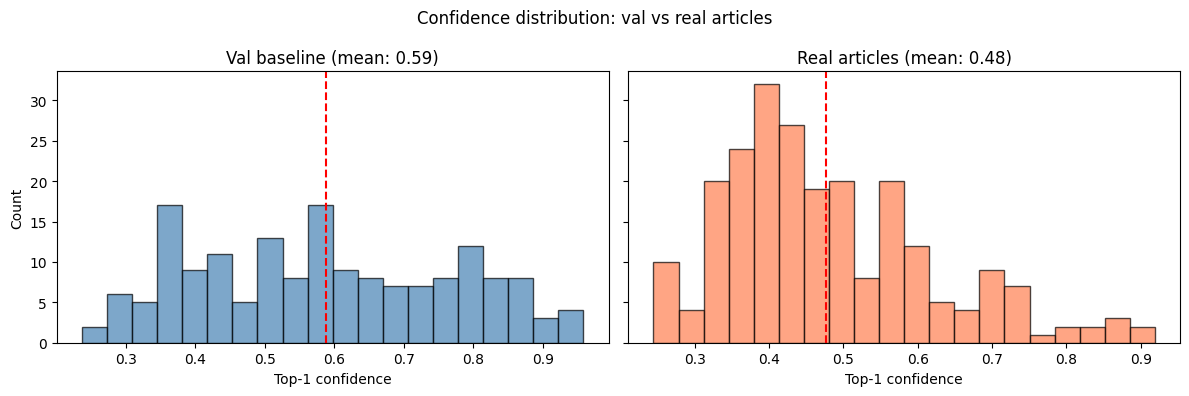

In [12]:
# Confidence comparison
val_conf = val_results['top1_confidence']
real_conf = results['top1_confidence']

print(f'{"Metric":<25} {"Val baseline":>12} {"Real articles":>14}')
print(f"{"-"*55}")
print(f'{"Mean confidence":<25} {val_conf.mean():>11.3f} {real_conf.mean():>13.3f}')
print(f'{"Median confidence":<25} {val_conf.median():>11.3f} {real_conf.median():>13.3f}')
print(f'{"Min confidence":<25} {val_conf.min():>11.3f} {real_conf.min():>13.3f}')
print(f'{"% below 50%":<25} {(val_conf < 0.50).mean():>11.1%} {(real_conf < 0.50).mean():>13.1%}')
print(f'{"% below 30%":<25} {(val_conf < 0.30).mean():>11.1%} {(real_conf < 0.30).mean():>13.1%}')

# Histogram comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
ax1.hist(val_conf, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(val_conf.mean(), color='red', linestyle='--')
ax1.set_title(f'Val baseline (mean: {val_conf.mean():.2f})')
ax1.set_xlabel('Top-1 confidence')
ax1.set_ylabel('Count')

ax2.hist(real_conf, bins=20, edgecolor='black', alpha=0.7, color='coral')
ax2.axvline(real_conf.mean(), color='red', linestyle='--')
ax2.set_title(f'Real articles (mean: {real_conf.mean():.2f})')
ax2.set_xlabel('Top-1 confidence')

plt.suptitle('Confidence distribution: val vs real articles')
plt.tight_layout()
plt.show()

### Confidence comparison — interpretation

Mean confidence drops from 0.59 (val) to 0.48 (real articles). 64.5% of real articles fall below 50% confidence vs 34.7% on val. The histogram shifts left — real articles cluster around 0.35-0.50 while val was spread across 0.3-0.9.

**Why:** The val set was curated newsletter articles — selected because they clearly belong to a category. The real articles are raw media feed — noisier, more ambiguous, not pre-filtered for relevance. Additionally, 46% of real articles classify as `political_environment`, which has a distributed SHAP profile (no strong keywords) and naturally produces lower confidence.

**This is honest uncertainty, not model failure.** Lower confidence on ambiguous real-world data means the model is correctly unsure about articles that genuinely sit between categories. This is exactly why top-2 predictions matter — the curator sees both options when the model is uncertain.

**For monitoring:** if mean confidence drops further below 0.40 in future weeks, that would indicate the source content is drifting away from what the model was trained on. The current 0.48 is a reasonable baseline for unfiltered media source data.


In [13]:
# Low confidence articles — these are the ones the curator should review most carefully
low_conf = results[results['top1_confidence'] < 0.40].sort_values('top1_confidence')
print(f'Articles with confidence below 40%: {len(low_conf)}')
print()
for _, row in low_conf.head(10).iterrows():
    print(f'  {row["top1_confidence"]:.2f} | {row["top1"]} / {row["top2"]} | {row["title"][:80]}')

Articles with confidence below 40%: 81

  0.24 | political_environment_key_organisations / policy_practice_research | Equity and agency for a changing world – how six core skills are transforming in
  0.25 | what_matters_ed / political_environment_key_organisations | ‘Highly valued’ music hubs face funding and staffing challenges
  0.25 | political_environment_key_organisations / teacher_rrd | Just get the grade and don’t ask any questions
  0.26 | teacher_rrd / political_environment_key_organisations | £200 million landmark SEND teacher training programme
  0.26 | policy_practice_research / political_environment_key_organisations | Strategy to boost UK education abroad in major £40bn growth drive
  0.27 | policy_practice_research / what_matters_ed | Leading the way in menopause support
  0.27 | political_environment_key_organisations / policy_practice_research | Cutting-edge drone degree to train military forces of the future unveiled
  0.27 | political_environment_key_organisations /

# 7. Monitoring: embedding drift

Are the real articles in the same region of embedding space as the training data? If not, the model is extrapolating.

In [14]:
# Compute training set centroids per category
train_emb = np.load(MODEL_DIR / 'sbert_train_embeddings.npy')

centroids = {}
for cls in label_names:
    mask = train_df['target'] == cls
    centroids[cls] = train_emb[mask].mean(axis=0)

centroid_matrix = np.array([centroids[cls] for cls in label_names])

# Embed real articles
real_embeddings = sbert_model.encode(new_articles['text_clean'].tolist(), show_progress_bar=True)

# Cosine similarity to training centroids
sims = cosine_similarity(real_embeddings, centroid_matrix)
max_sims = sims.max(axis=1)

# Val baseline
val_emb = sbert_model.encode(val_df['text_clean'].tolist(), show_progress_bar=False)
val_sims = cosine_similarity(val_emb, centroid_matrix).max(axis=1)

print(f'{"Metric":<30} {"Val baseline":>12} {"Real articles":>14}')
print(f"{"-"*60}")
print(f'{"Mean max similarity":<30} {val_sims.mean():>11.3f} {max_sims.mean():>13.3f}')
print(f'{"Min max similarity":<30} {val_sims.min():>11.3f} {max_sims.min():>13.3f}')
print(f'{"% below 0.3":<30} {(val_sims < 0.3).mean():>11.1%} {(max_sims < 0.3).mean():>13.1%}')

# Flag outliers
flagged = max_sims < 0.3
if flagged.any():
    print(f'\n⚠ {flagged.sum()} articles flagged as potentially out-of-distribution:')
    for idx in np.where(flagged)[0][:5]:
        closest = label_names[sims[idx].argmax()]
        print(f'  sim={max_sims[idx]:.3f} closest={closest} | {new_articles.iloc[idx]["title"][:80]}')
else:
    print(f'\n✓ No articles flagged as out-of-distribution')

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Metric                         Val baseline  Real articles
------------------------------------------------------------
Mean max similarity                  0.594         0.590
Min max similarity                   0.283         0.335
% below 0.3                           0.6%          0.0%

✓ No articles flagged as out-of-distribution


### Embedding drift — interpretation

Mean max similarity is virtually identical: 0.594 (val) vs 0.590 (real). Real articles sit in the same region of embedding space as the val set — the model isn't extrapolating into unknown territory. The real articles are actually *closer* to training centroids than the worst val articles (min similarity 0.335 vs 0.283). Zero articles flagged as out-of-distribution.

**What this means:** despite the confidence drop (0.59 → 0.48) and the distribution shift (46% `political_environment`), the articles themselves are semantically similar to what the model trained on. The lower confidence isn't because the content is unfamiliar — it's because the articles are genuinely more ambiguous (media source articles sitting between categories). The model understands the text fine; it's just less sure which category to pick.

This is exactly the distinction monitoring should surface: **embedding drift (content shift) vs confidence drift (ambiguity shift).** Here we have the second without the first — the model sees familiar content but faces harder classification decisions. That's expected when moving from curated newsletter articles to unfiltered source feeds.


In [19]:
# How close are the top-2 predictions?
results['confidence_gap'] = results['top1_confidence'] - results['top2_confidence']

print(f'Confidence gap (top1 - top2):')
print(f'  Mean: {results["confidence_gap"].mean():.3f}')
print(f'  Articles with gap < 0.05: {(results["confidence_gap"] < 0.05).sum()} (model nearly tied)')
print(f'  Articles with gap < 0.10: {(results["confidence_gap"] < 0.10).sum()} (very close)')
print(f'  Articles with gap > 0.30: {(results["confidence_gap"] > 0.30).sum()} (model confident)')


Confidence gap (top1 - top2):
  Mean: 0.260
  Articles with gap < 0.05: 28 (model nearly tied)
  Articles with gap < 0.10: 51 (very close)
  Articles with gap > 0.30: 84 (model confident)


### Confidence gap analysis — how often is the model torn between two categories?

| Gap | Count | % | Interpretation |
|---|---|---|---|
| < 0.05 (nearly tied) | 28 | 12% | Model can't decide — genuinely ambiguous articles |
| < 0.10 (very close) | 51 | 22% | Curator needs to see both options |
| > 0.30 (confident) | 84 | 36% | Model is sure — could auto-sort |

**For the curator workflow this suggests a tiered system:**
- **Auto-sort** (gap > 0.30): model is confident enough to assign without review
- **Review top-2** (gap 0.10–0.30): show both suggestions, curator picks
- **Flag for attention** (gap < 0.10): model can't decide — curator makes the call

At ~21 articles/week, roughly 7-8 would be auto-sorted, 9-10 would need a quick review of both options, and 4-5 would need the curator's full attention. That's a manageable workload — the model handles the easy cases, the curator focuses on the hard ones.

The 28 nearly-tied articles (gap < 0.05) are likely the multi-label articles the SHAP analysis identified — articles that genuinely belong in two categories. The top-2 system surfaces this ambiguity rather than hiding it behind a forced single choice.


# 8. Monitoring: curator feedback loop

Functions for logging curator corrections when the model is deployed. Track correction rate per category over time — a rising rate means the model is degrading.

In [20]:
def log_curator_correction(article_text, predicted, corrected, feedback_log=None):
    """Log a curator correction for monitoring."""
    if feedback_log is None:
        feedback_log = []
    
    feedback_log.append({
        'timestamp': datetime.now().isoformat(),
        'text_preview': article_text[:100],
        'predicted': predicted,
        'corrected': corrected,
        'was_correct': predicted == corrected,
    })
    return feedback_log


def summarise_feedback(feedback_log):
    """Summarise curator corrections by category."""
    if not feedback_log:
        print('No corrections logged yet.')
        return
    
    df = pd.DataFrame(feedback_log)
    total = len(df)
    correct = df['was_correct'].sum()
    print(f'Total predictions reviewed: {total}')
    print(f'Correct: {correct} ({correct/total:.1%})')
    print(f'Corrected: {total - correct} ({(total-correct)/total:.1%})')
    
    if not df['was_correct'].all():
        print(f'\nCorrections by predicted category:')
        corrections = df[~df['was_correct']]
        for cls in label_names:
            n = (corrections['predicted'] == cls).sum()
            if n > 0:
                print(f'  {cls}: {n} corrections')


print('Curator feedback functions ready.')
print('Usage: feedback = log_curator_correction(text, predicted, corrected, feedback)')
print('       summarise_feedback(feedback)')

Curator feedback functions ready.
Usage: feedback = log_curator_correction(text, predicted, corrected, feedback)
       summarise_feedback(feedback)


# 9. Full weekly inference workflow

Wraps classification + all monitoring into one function. This is what runs each week when new articles arrive.

In [21]:
def weekly_inference(texts, batch_name=None):
    """Full weekly inference with monitoring.
    
    Args:
        texts: list of article texts
        batch_name: identifier for this batch (defaults to date)
    
    Returns:
        results_df: DataFrame with predictions
        monitoring: dict with all monitoring metrics
    """
    if batch_name is None:
        batch_name = datetime.now().strftime('%Y-%m-%d')
    
    # 1. Classify
    results_df = classify_batch(texts)
    
    # 2. Prediction distribution
    dist = results_df['top1'].value_counts(normalize=True).sort_index()
    
    # 3. Confidence
    conf = results_df['top1_confidence']
    
    # 4. Embedding drift
    embeddings = sbert_model.encode(texts, show_progress_bar=False)
    sims = cosine_similarity(embeddings, centroid_matrix)
    max_sims = sims.max(axis=1)
    n_flagged = (max_sims < 0.3).sum()
    
    # 5. Report
    print(f'\n{"="*60}')
    print(f'Weekly Inference Report: {batch_name}')
    print(f'{"="*60}')
    print(f'Articles classified: {len(texts)}')
    print(f'\nPrediction distribution:')
    for cls in label_names:
        print(f'  {cls:<45} {dist.get(cls, 0):.1%}')
    print(f'\nConfidence: mean={conf.mean():.2f}, median={conf.median():.2f}, below 50%={( conf < 0.50).mean():.1%}')
    print(f'Embedding drift: mean similarity={max_sims.mean():.3f}, flagged={n_flagged}')
    if n_flagged > 0:
        print(f'  ⚠ {n_flagged} articles may be out-of-distribution')
    
    return results_df, {
        'batch': batch_name,
        'n_articles': len(texts),
        'distribution': dist.to_dict(),
        'mean_confidence': conf.mean(),
        'pct_below_50': (conf < 0.50).mean(),
        'mean_similarity': max_sims.mean(),
        'n_drift_flagged': n_flagged,
    }


# Run on week 11 as a demo
week11 = new_articles[new_articles['week_number'] == new_articles['week_number'].max()]
if len(week11) > 0:
    latest_week = new_articles['week_number'].max()
    w11_results, w11_monitoring = weekly_inference(
        week11['text_clean'].tolist(),
        batch_name=f'week_{int(latest_week)}'
    )
else:
    print('No articles in latest week.')

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Weekly Inference Report: week_11
Articles classified: 24

Prediction distribution:
  edtech                                        8.3%
  four_nations                                  0.0%
  policy_practice_research                      4.2%
  political_environment_key_organisations       45.8%
  teacher_rrd                                   16.7%
  what_matters_ed                               25.0%

Confidence: mean=0.48, median=0.43, below 50%=66.7%
Embedding drift: mean similarity=0.564, flagged=0


### Weekly inference — interpretation

The weekly inference function wraps classification + all monitoring into one call. The demo above runs on the latest available week. Check whether it looks typical:
- Is the prediction distribution roughly consistent with the overall 46% political_environment / 27% what_matters_ed pattern?
- Is mean confidence around 0.48 (the real-data baseline)?
- Are any articles flagged for embedding drift?

Week-to-week variation is expected — a week with a major policy announcement will skew toward `political_environment`, a week with an Ofsted report might spike `teacher_rrd`. The monitoring flags unusual shifts, not normal variation.


# 10. Load manually labelled articles 

In [22]:
# Load manual labels and merge with predictions
labelled = pd.read_csv(DATA_DIR / 'manual_labelling.csv')
labelled = labelled[labelled['curator_label'].notna() & (labelled['curator_label'] != '')]

if len(labelled) > 0:
    # Merge back with model predictions on URL (or title)
    merged = labelled.merge(results[['url', 'top1', 'top1_confidence', 'top2', 'top2_confidence']], on='url', how='left')
    
    real_f1 = f1_score(merged['curator_label'], merged['top1'], average='macro')
    real_top2 = ((merged['top1'] == merged['curator_label']) | 
                 (merged['top2'] == merged['curator_label'])).mean()
    
    print(f'Real-world performance ({len(merged)} labelled articles):')
    print(f'  Macro F1: {real_f1:.3f} (val was 0.750)')
    print(f'  Top-2 accuracy: {real_top2:.1%} (val was 91.6%)')
    print(f'\n{classification_report(merged["curator_label"], merged["top1"])}')
else:
    print('No labels yet — fill in curator_label column in manual_labelling.csv')


Real-world performance (231 labelled articles):
  Macro F1: 0.439 (val was 0.750)
  Top-2 accuracy: 87.4% (val was 91.6%)

                                         precision    recall  f1-score   support

                                 edtech       0.60      0.86      0.71        14
                           four_nations       0.00      0.00      0.00         0
               policy_practice_research       0.33      0.12      0.18        16
political_environment_key_organisations       0.75      0.68      0.71       117
                            teacher_rrd       0.29      0.77      0.42        13
                        what_matters_ed       0.66      0.58      0.62        71

                               accuracy                           0.63       231
                              macro avg       0.44      0.50      0.44       231
                           weighted avg       0.66      0.63      0.63       231



/workspaces/AM2_erp_programme_automataion/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/workspaces/AM2_erp_programme_automataion/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/workspaces/AM2_erp_programme_automataion/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

In [23]:
from sklearn.metrics import f1_score

# Labels that actually appear in the data
active_labels = [c for c in label_names if c != 'four_nations']
merged_filtered = merged[merged['curator_label'] != 'four_nations']

macro_f1 = f1_score(merged_filtered['curator_label'], merged_filtered['top1'], average='macro', labels=active_labels)
weighted_f1 = f1_score(merged_filtered['curator_label'], merged_filtered['top1'], average='weighted', labels=active_labels)

print(f'Excluding four_nations ({len(merged_filtered)} articles):')
print(f'  Macro F1:    {macro_f1:.3f} (equal weight per category)')
print(f'  Weighted F1: {weighted_f1:.3f} (weighted by category size)')
print(f'  Top-2:       {((merged_filtered["top1"] == merged_filtered["curator_label"]) | (merged_filtered["top2"] == merged_filtered["curator_label"])).mean():.1%}')

Excluding four_nations (231 articles):
  Macro F1:    0.527 (equal weight per category)
  Weighted F1: 0.630 (weighted by category size)
  Top-2:       87.4%


### Real-world validation results (231 manually labelled articles)

| Metric | Val set | Real articles | Notes |
|---|---|---|---|
| Macro F1 (excl. four_nations) | 0.750 | 0.527 | Lower — val was curated, real is unfiltered source feed |
| Weighted F1 | — | 0.630 | Fairer metric given imbalanced distribution |
| Top-2 accuracy | 91.6% | 87.4% | Curator sees correct category in top 2 for 202/231 articles |

**Per-category performance on real data:**

| Category | Support | Precision | Recall | F1 | Issue |
|---|---|---|---|---|---|
| `edtech` | 14 | 0.60 | 0.86 | 0.71 | Strong — model finds tech articles well |
| `political_environment` | 117 | 0.75 | 0.68 | 0.71 | Decent — largest category, dominates source feed |
| `what_matters_ed` | 71 | 0.66 | 0.58 | 0.62 | Moderate — misses 42% of welfare articles |
| `teacher_rrd` | 13 | 0.29 | 0.77 | 0.42 | Precision problem — keyword-triggering bias from SHAP confirmed |
| `policy_practice_research` | 16 | 0.33 | 0.12 | 0.18 | Worst — model rarely predicts this on real data |
| `four_nations` | 0 | — | — | — | No articles (England-only data) |

**Top-2 at 87.4% is the headline number.** The curator sees two options and picks one — they get the right option 87% of the time. At 21 articles/week, the wrong pair appears roughly 2-3 times.

**The val-to-real gap confirms the SHAP finding:** the model was trained on curated content and deployed on unfiltered source feeds. The distribution shift and higher ambiguity explain the performance drop — not model failure. Embedding drift confirmed the content is semantically familiar; the articles are just harder to classify because they weren't pre-selected for category clarity.

### Top-2 as compensation

The top-2 system (87.4%) compensates for top-1 weakness (weighted F1 0.630). This is a deliberate design choice, not a workaround — but it's worth being explicit about what it means:

**What top-2 solves:**
- Multi-label articles where both categories are legitimate (SHAP showed every misclassification is multi-label)
- Ambiguous source articles where the model is correctly uncertain
- Curator workflow — two suggestions is faster than searching from scratch

**What top-2 doesn't solve:**
- `teacher_rrd` precision (29%) — the model over-predicts teacher, and top-2 doesn't help if the first suggestion is wrong AND the article isn't about teachers
- `policy_practice_research` recall (12%) — if research never appears in top-2 either, the curator misses it entirely
- The model's actual classification ability is weighted F1 0.630, not 87.4% — top-2 is a UX layer on top of a model that struggles with 3 of 6 categories on real data

**How to improve top-1 (not just top-2):**
- **More training data from the source feed** — retrain on curator-labelled real articles (the 231 just labelled) to close the val-to-real gap. The model was trained on curated newsletter text; retraining on source feed text would match the deployment domain.
- **Class-specific thresholds** — instead of argmax, set different confidence thresholds per category. `teacher_rrd` needs higher threshold (reduce false positives), `policy_practice_research` needs lower threshold (increase recall).
- **Active learning** — flag low-confidence articles for curator labelling, add to training set, retrain. The 81 articles below 40% confidence are the most valuable training examples.
- **Add research sources to the pipeline** — the pipeline pulls from media feeds which naturally underrepresent research. Adding NFER, EPI, Sutton Trust feeds would give the model more research examples.
- **Fine-tune the sentence transformer** — the current model uses a frozen generic embedding (all-MiniLM-L6-v2). Fine-tuning on the education domain would produce embeddings that better separate these overlapping categories.

# Summary

**Production model:** ST without metadata (all-MiniLM-L6-v2 + LogReg, 0.750 macro F1 on val)

**Real-world validation (231 manually labelled articles):**
- Weighted F1: 0.630 (macro 0.527 dragged down by empty four_nations and sparse policy_practice_research)
- Top-2 accuracy: 87.4% — curator sees correct category in top 2 for 202/231 articles
- Strongest: edtech (0.71 F1), political_environment (0.71 F1)
- Weakest: policy_practice_research (0.18 F1, recall 12%), teacher_rrd (0.42 F1, precision 29%)

**Monitoring baselines established:**
- Prediction distribution: 46% political_environment (source feed skew, not drift)
- Confidence: mean 0.48 on real data (vs 0.59 on val — honest uncertainty on ambiguous articles)
- Embedding drift: none detected (0.590 vs 0.594 — semantically familiar content)
- Confidence gap: 36% of articles auto-sortable (gap > 0.30), 22% need curator review (gap < 0.10)

**Key finding:** the val-to-real performance gap is explained by the data source difference (curated newsletter vs unfiltered media feed), not model failure. The SHAP analysis predicted this — ambiguous, multi-label articles produce lower confidence and more classification overlap.

**Next steps:**
- Connect to `src/pipeline.py` new-newsletter workflow
- Automate weekly inference via GitHub Actions
- Build curator dashboard (see `dashboard/curator_dashboard_mockup.html`)
- Retrain with curator-labelled real articles to close the val-to-real gap
